# AlexNet Benchmark

In [1]:
model_name = "AlexNet"

import torch
from torch import nn
from torchvision import models
import torch_mlir
import numpy as np
import iree.compiler
import iree.runtime

import warnings
warnings.filterwarnings("ignore")

from timeit import timeit as ti
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def compile_str(mlir):
    return iree.runtime.load_vm_flatbuffer(
        iree.compiler.compile_str(
            mlir, input_type="tosa", target_backends=["llvm-cpu"],
            extra_args=[
                "--iree-llvmcpu-target-cpu-features=host",
                "--iree-stream-partitioning-favor=max-concurrency",
                "--iree-flow-zero-fill-empty-tensors",
                "--iree-llvmcpu-fail-on-out-of-bounds-stack-allocation=0",
                "--iree-opt-const-eval",
                "--iree-opt-const-expr-hoisting",
                "--iree-opt-numeric-precision-reduction",
                "--iree-opt-strip-assertions"
            ]
        ),
        backend="llvm-cpu"
    )

def compile_file(filename):
    with open(filename) as f:
        return compile_str(f.read())
    
def get_dataframe(forward, backward, item):
    return pd.concat([
        pd.DataFrame({
            "time": forward,
            "pass": "Forward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": backward,
            "pass": "Backward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": forward + backward,
            "pass": "Full",
            "item": item
        }, index=[0]),
    ])

def timeit(stmt, n=100):
    return ti(stmt, globals=globals(), number=n) * 1000 / n

## Prepare

In [2]:
MAGIC_NUM = 7777e-5

model = models.alexnet(pretrained=False).train(False)
model.load_state_dict({k: torch.ones_like(v) * MAGIC_NUM for k, v in model.state_dict().items()})
model = torch.compile(model, backend="inductor")

recompute, storeall = [
    compile_file(x) for x in ["recompute.mlir", "storeall.mlir"]
]

## Experimental

In [3]:
image = torch.randn(1, 3, 224, 224, requires_grad=True)
output = model(image)
grad = torch.randn_like(output)

image_np = image.detach().numpy()
grad_np = grad.numpy()

df = pd.DataFrame()

No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'


### PyTorch (Baseline)

In [4]:
baseline_f = timeit("model(image)")
baseline_b = timeit("torch.autograd.grad(output, [image], grad, retain_graph=True)")
df = pd.concat([df, get_dataframe(baseline_f, baseline_b, "Torch Dynamo")])

Using FallbackKernel: aten._adaptive_avg_pool2d_backward
Using FallbackKernel: aten.max_pool2d_with_indices_backward


### Nabla without Optim

In [5]:
f = timeit("recompute.forward(image_np)")
b = timeit("recompute.dforward(grad_np)")
df = pd.concat([df, get_dataframe(f, b, "Nabla")])

### Nabla with Optim

In [6]:
f = timeit("storeall.forward(image_np)")
b = timeit("storeall.dforward(grad_np)")
df = pd.concat([df, get_dataframe(f, b, "Nabla Optim")])

## Result

In [7]:
df.style.hide(axis="index")

time,pass,item
15.917889,Forward,Torch Dynamo
73.730877,Backward,Torch Dynamo
89.648766,Full,Torch Dynamo
17.395022,Forward,Nabla
20.578929,Backward,Nabla
37.973951,Full,Nabla
19.831051,Forward,Nabla Optim
2.646048,Backward,Nabla Optim
22.477098,Full,Nabla Optim


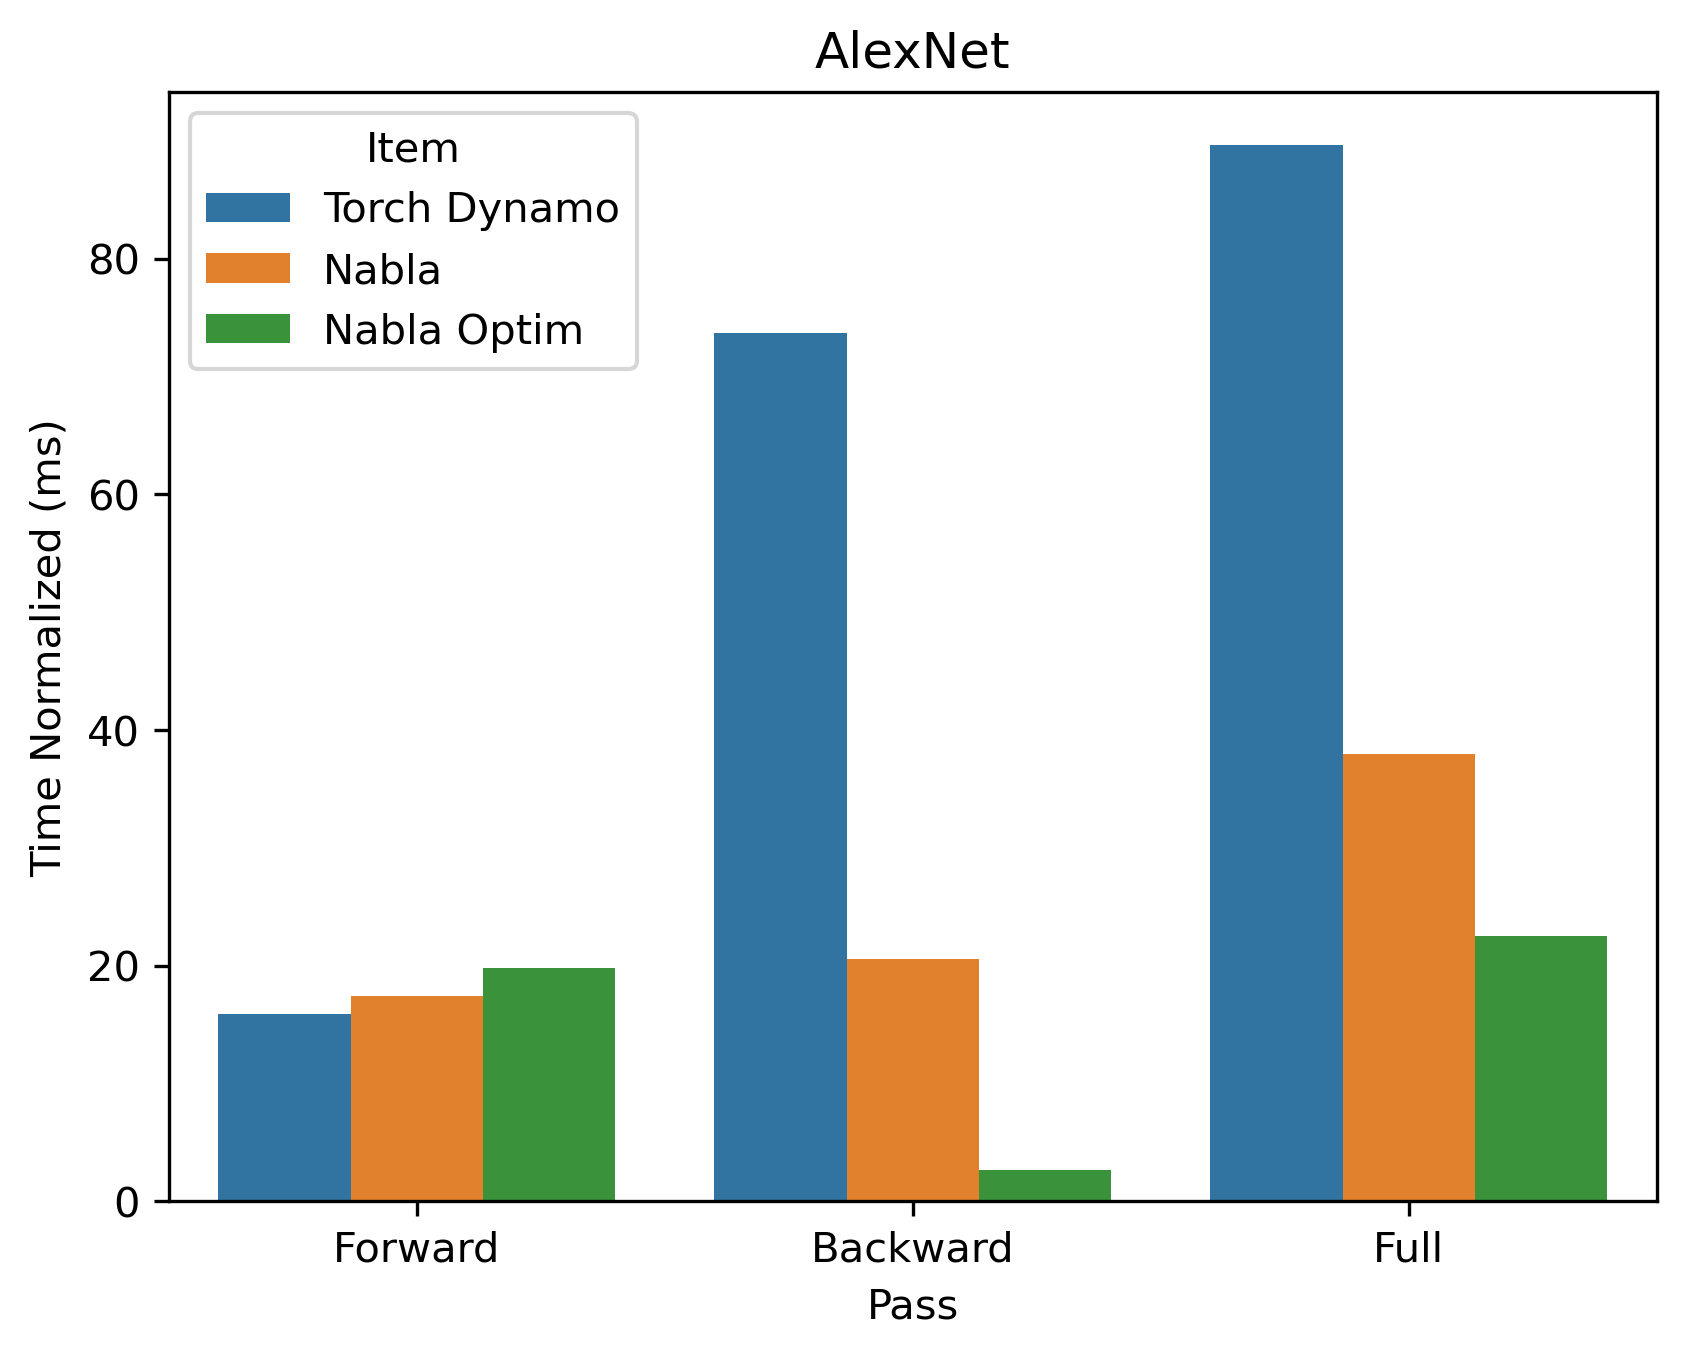

In [8]:
plt.rcParams["figure.dpi"] = 300

sns.barplot(df, x="pass", y="time", hue="item")
plt.xlabel("Pass")
plt.ylabel("Time Normalized (ms)")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-time.png")

In [9]:
forward = df[df["pass"] == "Forward"]
forward["acceleration"] = baseline_f / forward["time"]
forward

,time,pass,item,acceleration
0,15.917889,Forward,Torch Dynamo,1.000000
0,17.395022,Forward,Nabla,0.915083
0,19.831051,Forward,Nabla Optim,0.802675


In [10]:
backward = df[df["pass"] == "Backward"]
backward["acceleration"] = baseline_b / backward["time"]
backward

,time,pass,item,acceleration
0,73.730877,Backward,Torch Dynamo,1.000000
0,20.578929,Backward,Nabla,3.582834
0,2.646048,Backward,Nabla Optim,27.864530


In [11]:
full = df[df["pass"] == "Full"]
full["acceleration"] = (baseline_b + baseline_f) / full["time"]
full

,time,pass,item,acceleration
0,89.648766,Full,Torch Dynamo,1.000000
0,37.973951,Full,Nabla,2.360796
0,22.477098,Full,Nabla Optim,3.988449


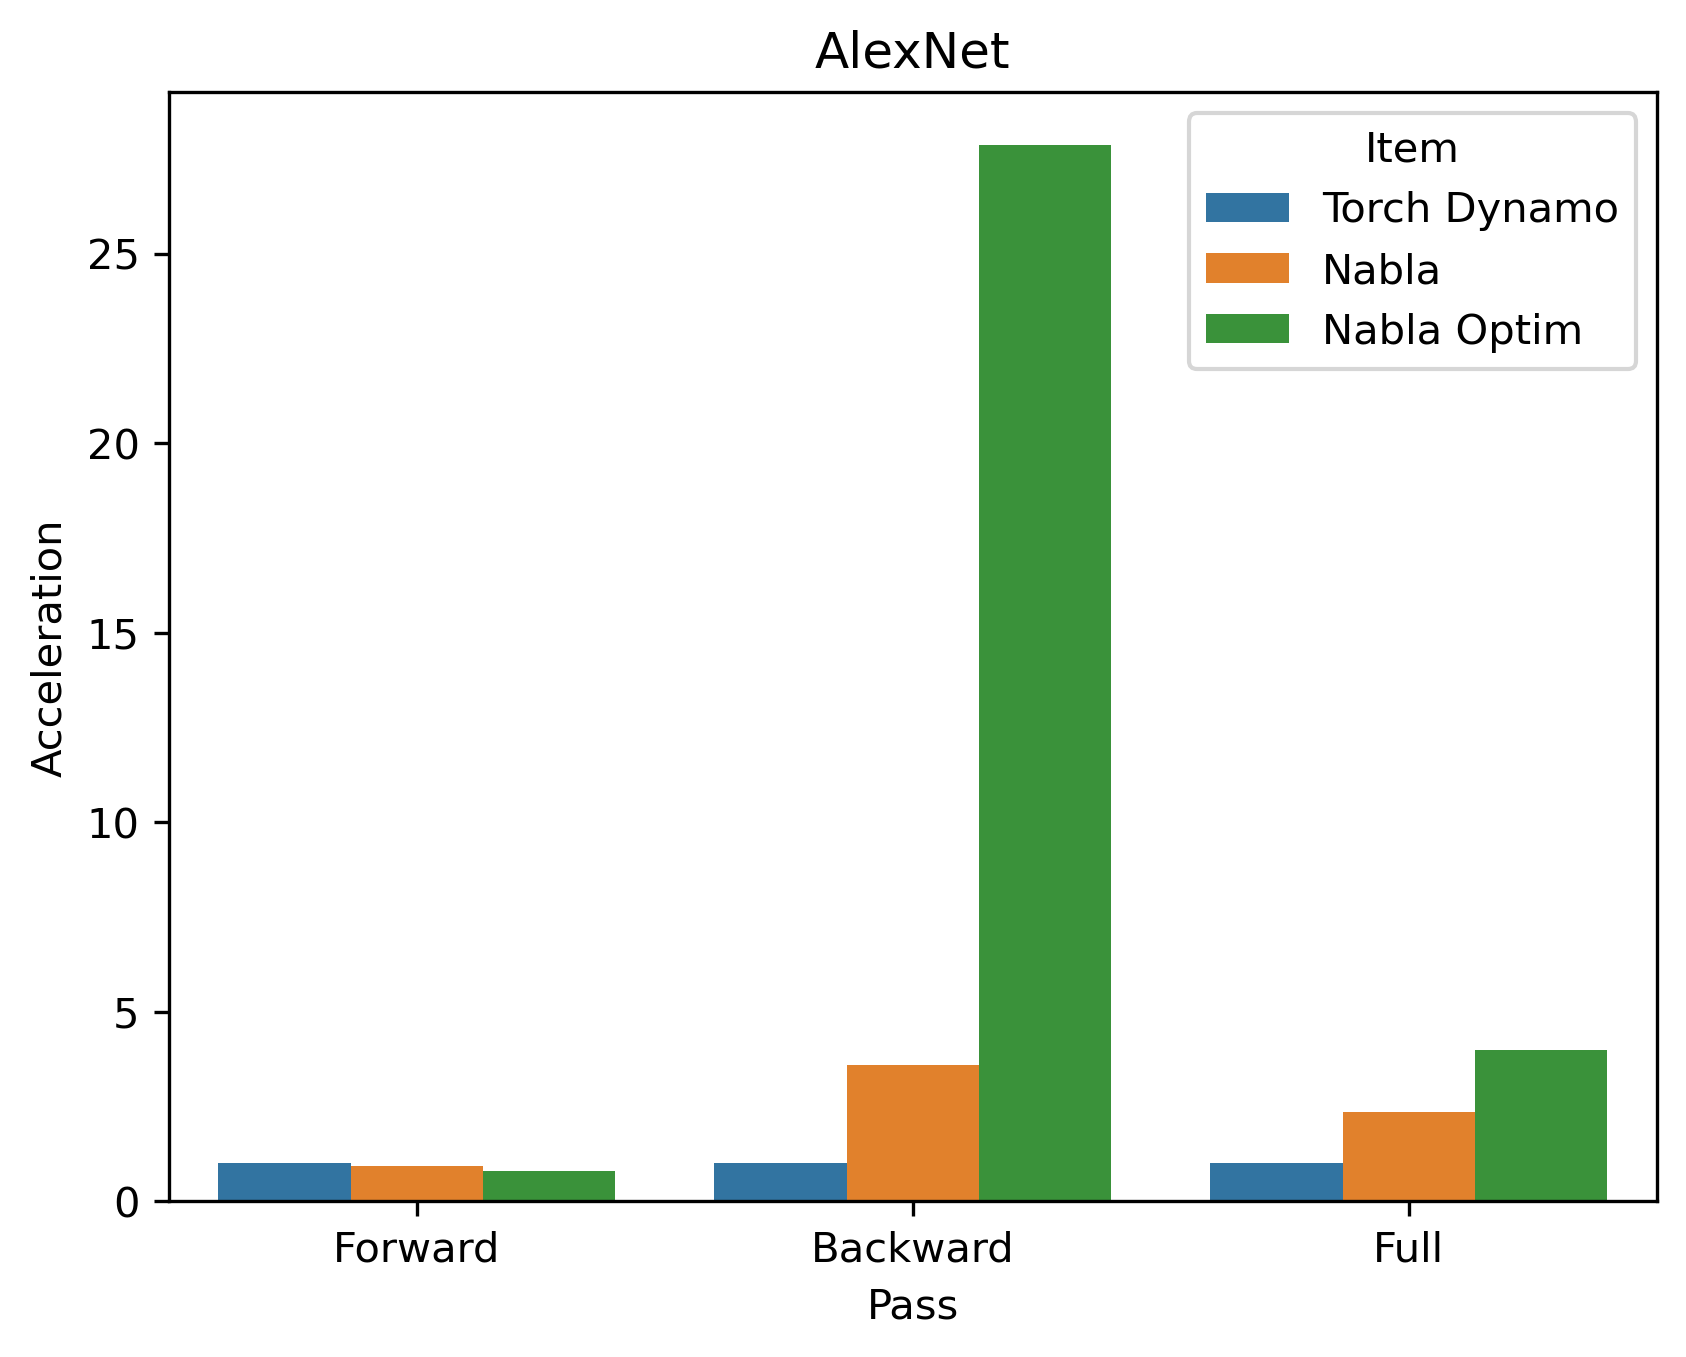

In [12]:
df = pd.concat([forward, backward, full])
df.to_csv(f"{model_name}.csv")

sns.barplot(df, x="pass", y="acceleration", hue="item")
plt.xlabel("Pass")
plt.ylabel("Acceleration")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-acceleration.png")